# Final Project: IMBD MOVIES
#### Authors: D. Whitney, C. Mott, B. Graeve
#### Course: CSC 5610
#### Date: 5/5/2026

### Part 1: Load and Clean Data

##### 1.1 Load Data

In [88]:
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pandas as pd
import numpy as np
from matplotlib.ticker import FuncFormatter
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, mean_absolute_percentage_error


movies_df = pd.read_csv('TMDB_movie_dataset_v11.csv')

display(movies_df.head())
movies_df.info()
movies_df.describe()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


<class 'pandas.DataFrame'>
RangeIndex: 1418445 entries, 0 to 1418444
Data columns (total 24 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1418445 non-null  int64  
 1   title                 1418427 non-null  str    
 2   vote_average          1418445 non-null  float64
 3   vote_count            1418445 non-null  int64  
 4   status                1418445 non-null  str    
 5   release_date          1103168 non-null  str    
 6   revenue               1418445 non-null  int64  
 7   runtime               1418445 non-null  int64  
 8   adult                 1418445 non-null  bool   
 9   backdrop_path         352346 non-null   str    
 10  budget                1418445 non-null  int64  
 11  homepage              145804 non-null   str    
 12  imdb_id               667862 non-null   str    
 13  original_language     1418445 non-null  str    
 14  original_title        1418427 non-null  str  

,id,vote_average,vote_count,revenue,runtime,budget,popularity
count,1.418445e+06,1.418445e+06,1.418445e+06,1.418445e+06,1.418445e+06,1.418445e+06,1.418445e+06
mean,8.988704e+05,1.555490e+00,1.512753e+01,6.216328e+05,4.396686e+01,2.354907e+05,1.011936e+00
std,4.774842e+05,2.857763e+00,2.852197e+02,1.970374e+07,6.067686e+01,5.074687e+06,6.807757e+00
min,2.000000e+00,0.000000e+00,0.000000e+00,-1.200000e+01,-2.800000e+01,0.000000e+00,0.000000e+00
25%,4.946380e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.570000e-02
50%,9.219990e+05,0.000000e+00,0.000000e+00,0.000000e+00,1.600000e+01,0.000000e+00,6.000000e-01
75%,1.316546e+06,1.000000e+00,1.000000e+00,0.000000e+00,8.500000e+01,0.000000e+00,7.030000e-01
max,1.689057e+06,1.000000e+01,3.449500e+04,5.000000e+09,1.440000e+04,1.000000e+09,2.994357e+03


##### 1.2 Drop unnecessary variables

In [89]:
# Drop columns that are not needed for analysis
temp_df = movies_df.drop(columns=['id', 'overview', 'title', 'original_title', 'backdrop_path', 
                                  'poster_path', 'imdb_id', 'homepage', 'status', 'tagline'])
movies_df = temp_df.copy()
movies_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1418445 entries, 0 to 1418444
Data columns (total 14 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   vote_average          1418445 non-null  float64
 1   vote_count            1418445 non-null  int64  
 2   release_date          1103168 non-null  str    
 3   revenue               1418445 non-null  int64  
 4   runtime               1418445 non-null  int64  
 5   adult                 1418445 non-null  bool   
 6   budget                1418445 non-null  int64  
 7   original_language     1418445 non-null  str    
 8   popularity            1418445 non-null  float64
 9   genres                795142 non-null   str    
 10  production_companies  603869 non-null   str    
 11  production_countries  732113 non-null   str    
 12  spoken_languages      759350 non-null   str    
 13  keywords              350703 non-null   str    
dtypes: bool(1), float64(2), int64(4), str(7)
memo

##### 1.3 Custom Helper Functions

In [90]:
def format_money(x, pos):
    '''
    Formats large numbers into human-readable strings with appropriate suffixes.
    '''
    if x >= abs(1e9):
        return f'${x * 1e-9:g}B'
    elif x >= abs(1e6):
        return f'${x*1e-6:g}M'
    elif x >= abs(1e3):
        return f'${x*1e-3:g}K'
    else:
        return f'${x:g}'

formatter = FuncFormatter(format_money)


##### 1.4 Convert Datatypes and Handle Missing Data

In [91]:
movies_df['release_date'] = pd.to_datetime(movies_df['release_date'])

for col in movies_df.select_dtypes(include=['int64', 'float64']).columns:
    if col not in ['vote_average', 'popularity']:
        movies_df[col] = movies_df[col].replace(0, pd.NA).astype('Int64' if movies_df[col].dtype == 'int64' else 'Float64')

movies_df['revenue'] = movies_df['revenue'].where((movies_df['revenue'] > 1e3) & (movies_df['revenue'] < 1.5e9), pd.NA).astype('Int64')
movies_df['budget'] = movies_df['budget'].where((movies_df['budget'] > 1e3) & (movies_df['budget'] < 1.5e9), pd.NA).astype('Int64')

movies_df.dropna(subset=['revenue'], inplace=True)
movies_df.reset_index(drop=True, inplace=True)

mlb = MultiLabelBinarizer(sparse_output=False)
mlb_encoded_df_list = []
non_ascii_regex = r'[^\x00-\x7F]+'

for col in movies_df.select_dtypes(include=['object', 'str', 'string']).columns:
    if movies_df[col].dropna().astype(str).str.contains(',').any():
        clean_series = movies_df[col].fillna('').astype(str).str.replace(non_ascii_regex, '', regex=True).str.lower()
        clean_lists = clean_series.str.split(',').apply(lambda x: [i.strip() for i in x if i.strip()])
        
        binary_matrix = mlb.fit_transform(clean_lists)
        col_names = [f"{col}_{cls}" for cls in mlb.classes_]
        
        temp_df = pd.DataFrame(binary_matrix, columns=col_names, index=movies_df.index).astype('bool')
        mlb_encoded_df_list.append(temp_df)
    else:
        clean_series = movies_df[col].fillna('').astype(str).str.lower().str.strip()
        dummies = pd.get_dummies(clean_series, prefix=col, drop_first=True).astype('bool')
        mlb_encoded_df_list.append(dummies)

mlb_encoded_df = pd.concat(mlb_encoded_df_list, axis=1)

category_counts = mlb_encoded_df.sum(axis=0)
reliable_cols = category_counts[category_counts > 100].index
mlb_encoded_df = mlb_encoded_df[reliable_cols]

encoded_df = pd.concat([movies_df, mlb_encoded_df], axis=1)

cols_to_drop = encoded_df.select_dtypes(include=['object', 'str', 'string', 'datetime']).columns

clean_df = encoded_df.drop(columns=cols_to_drop)
clean_df = clean_df.dropna()

display(clean_df.shape)

(9832, 243)

### Part 2: Baseline Model

Mean Squared Error: 5000429259200708.0
Mean Absolute Percentage Error: 89.01784552698481
R^2 Score: 0.7525565466992742


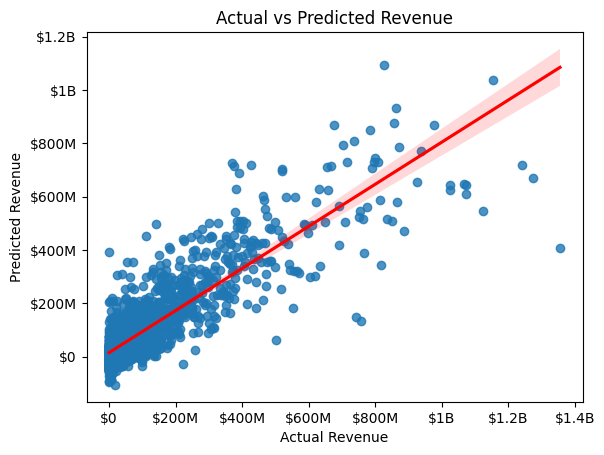

In [92]:
X = clean_df.drop(columns=['revenue'])
y = clean_df['revenue']

x_train, x_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.3, 
    random_state=42
)


model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)


mse = mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Percentage Error: {mape}")
print(f"R^2 Score: {r2}")


ax = sns.regplot(x=y_test, y=y_pred, line_kws={"color": "red"})
ax.set_xlabel("Actual Revenue")
ax.set_ylabel("Predicted Revenue")
ax.set_title("Actual vs Predicted Revenue")
plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)
plt.show()


### Part 3: Feature Engineering
##### 3.1 Clean and Engineer Features

In [93]:

engineered_df = encoded_df.copy()

median_budget = int(engineered_df['budget'].median())
engineered_df['budget'] = engineered_df['budget'].fillna(median_budget)

engineered_df['runtime'] = engineered_df['runtime'].where(engineered_df['runtime'] > 0, pd.NA)
median_runtime = int(engineered_df['runtime'].median())
engineered_df['runtime'] = engineered_df['runtime'].fillna(median_runtime)

engineered_df['release_month'] = engineered_df['release_date'].dt.month_name().astype('category')
engineered_df['release_year'] = engineered_df['release_date'].dt.year.astype('Int64')

'''
bins = [0, 40, 301, np.inf] 
labels = ['Short Film', 'Feature Film', 'TV Show/Collection']
engineered_df['media_format'] = pd.cut(
    engineered_df['runtime'], 
    bins=bins, 
    labels=labels, 
    right=False 
)
'''

engineered_df['num_genres'] = engineered_df['genres'].apply(lambda x: len(str(x).split(',')) if pd.notna(x) and str(x).strip() != '' else 0)
engineered_df['num_production_companies'] = engineered_df['production_companies'].apply(lambda x: len(str(x).split(',')) if pd.notna(x) and str(x).strip() != '' else 0)
engineered_df['num_production_countries'] = engineered_df['production_countries'].apply(lambda x: len(str(x).split(',')) if pd.notna(x) and str(x).strip() != '' else 0)
engineered_df['num_spoken_languages'] = engineered_df['spoken_languages'].apply(lambda x: len(str(x).split(',')) if pd.notna(x) and str(x).strip() != '' else 0)

engineered_df = pd.get_dummies(engineered_df, columns=['release_month'], drop_first=True)

cols_to_drop = engineered_df.select_dtypes(include=['object', 'str', 'string', 'datetime']).columns
engineered_df.drop(columns=cols_to_drop, inplace=True)

for col in engineered_df.select_dtypes(include=['int64', 'float64']).columns:
    if engineered_df[col].dtype == 'int64':
        engineered_df[col] = engineered_df[col].astype('Int64')
    else:
        engineered_df[col] = engineered_df[col].astype('Float64')

engineered_df.dropna(inplace=True)
engineered_df.reset_index(drop=True, inplace=True)

display(engineered_df.shape)




(15601, 259)

##### 3.3 Feature Engineered Model

Mean Squared Error: 3574154446299866.5
Mean Absolute Percentage Error: 181.23671330164166
R^2 Score: 0.7430279447524422


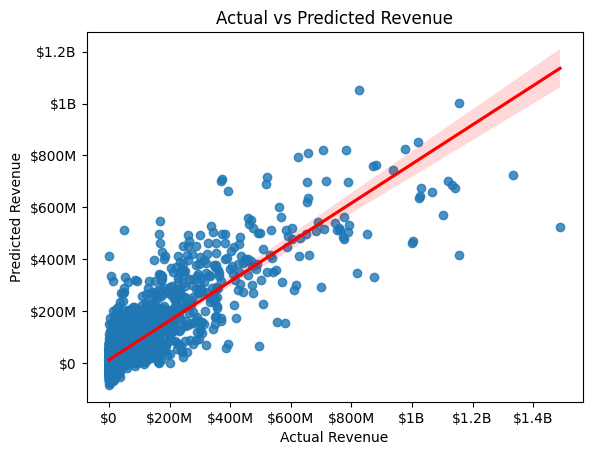

In [94]:
X = engineered_df.drop(columns=['revenue'])
y = engineered_df['revenue']
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Percentage Error: {mape}")
print(f"R^2 Score: {r2}")

ax = sns.regplot(x=y_test, y=y_pred, line_kws={"color": "red"})
ax.set_xlabel("Actual Revenue")
ax.set_ylabel("Predicted Revenue")
ax.set_title("Actual vs Predicted Revenue")
plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)
plt.show()

### Part 4: Additional Data

TESTING

##### 4.# Model Improved with Additional Data


### Part 5: More Complex Models

### Part 6: Model Comparisons

### Part 7: Minimum Model

### Part 8: Final Analysis